# Projeto Final – Mineração de Dados

**Nome do Aluno:** Marcelo Massashi Simonae  
**Disciplina:** Mineração de Dados  
**Professor:** Danilo S. Sanches  

## Objetivo
Desenvolver um processo completo de Mineração de Dados utilizando técnicas de pré-processamento, seleção de características (Filter e Wrapper), classificação e explicabilidade de modelos (SHAP) na base `Employee Analysis | Attrition Report`.

In [1]:
# Instalação da biblioteca SHAP (caso não esteja instalada no ambiente)
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Configuração do SHAP para exibição em notebooks
shap.initjs()

# Carregando o Dataset Oficial IBM HR Analytics
url = 'https://raw.githubusercontent.com/msimonae/HREmployeeAttrition/main/HR%20Employee%20Attrition.csv'
df = pd.read_csv(url)

# Quantidade de registros e atributos
print("Quantidade de registros e atributos:", df.shape)

# Tipos de dados presentes na base
print("\nTipos de dados presentes:")
print(df.dtypes)

# Quantidade de valores ausentes por atributo
print("\nQuantidade de valores ausentes por atributo:")
print(df.isnull().sum())

Quantidade de registros e atributos: (1470, 35)

Tipos de dados presentes:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours  

## 1. Pré-processamento e Separação dos Dados
Para evitar o *Data Leakage*, carregamos os dados, removemos colunas irrelevantes (ID e colunas constantes) e aplicamos a divisão entre treino e teste antes de qualquer transformação.

In [2]:
# Transformando a variável alvo 'Attrition' em binária (1 = Yes, 0 = No)
y = df['Attrition'].map({'Yes': 1, 'No': 0})

# Removendo o Target e colunas que não agregam poder preditivo (IDs e constantes)
cols_to_drop = ['Attrition', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
X = df.drop(columns=cols_to_drop)

# Separação com stratify para garantir a proporção da classe alvo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Separação das variáveis numéricas e categóricas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Pipelines de transformação
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# Ajuste restrito ao Treinamento (prevenção de Leakage)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(f"Dimensão dos dados processados: {X_train_proc.shape[1]} atributos.")

Dimensão dos dados processados: 49 atributos.


## Distribuição da Variável Alvo 'Attrition'

Vamos visualizar a distribuição da variável alvo para entender a proporção de funcionários que sofrem Attrition ('Yes') versus os que não sofrem ('No').

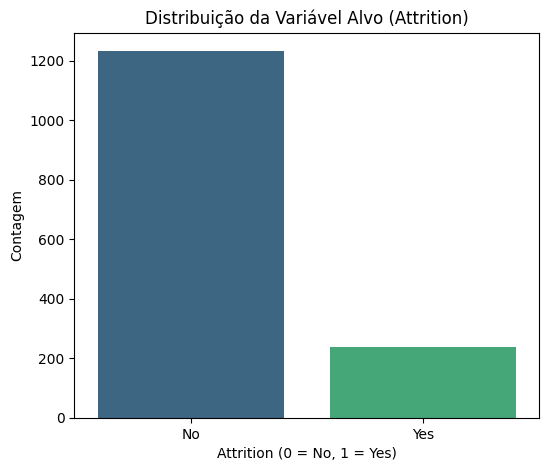

In [3]:
plt.figure(figsize=(6, 5))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo (Attrition)')
plt.xlabel('Attrition (0 = No, 1 = Yes)')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

## 2. Seleção de Características (Feature Selection)
Definimos **k = 10** como quantidade padrão de atributos. Vamos aplicar as abordagens **Filter** (Mutual Information) e **Wrapper** (RFE).

In [5]:
# =====================================================================
# Seleção de Features com Filter e Wrapper
# =====================================================================

k_features = 10

print("--- 1. Método Filter (Mutual Information) ---")
# Fixando random_state dentro do mutual_info_classif para garantir reprodutibilidade
filter_selector = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
    k=k_features
)
filter_selector.fit(X_train_proc, y_train)

# Atualiza filter_features para refletir a seleção atual
filter_features = set(feature_names[filter_selector.get_support()])
print("Selecionadas (com prefixos completos para verificação interna):")
for f in sorted(filter_features):
    print(f" - {f}")

print("\n--- 2. Método Wrapper (RFE) ---")
# Utilizando RandomForest como estimador base para o RFE
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
wrapper_selector = RFE(estimator=rf_base, n_features_to_select=k_features)
wrapper_selector.fit(X_train_proc, y_train)

# Atualiza wrapper_features para refletir a seleção atual
wrapper_features = set(feature_names[wrapper_selector.get_support()])
print("Selecionadas (com prefixos completos para verificação interna):")
for f in sorted(wrapper_features):
    print(f" - {f}")

--- 1. Método Filter (Mutual Information) ---
Selecionadas (com prefixos completos para verificação interna):
 - cat__MaritalStatus_Married
 - cat__OverTime_Yes
 - num__Age
 - num__JobLevel
 - num__MonthlyIncome
 - num__PercentSalaryHike
 - num__StockOptionLevel
 - num__TotalWorkingYears
 - num__YearsAtCompany
 - num__YearsWithCurrManager

--- 2. Método Wrapper (RFE) ---
Selecionadas (com prefixos completos para verificação interna):
 - num__Age
 - num__DailyRate
 - num__DistanceFromHome
 - num__HourlyRate
 - num__MonthlyIncome
 - num__MonthlyRate
 - num__PercentSalaryHike
 - num__TotalWorkingYears
 - num__YearsAtCompany
 - num__YearsWithCurrManager


Backup

In [16]:
k_features = 10

print("--- 1. Método Filter (Mutual Information) ---")
filter_selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
filter_selector.fit(X_train_proc, y_train)

# Atualiza filter_features para garantir que o conjunto reflita a seleção atual
filter_features = set(feature_names[filter_selector.get_support()])
print("Selecionadas (com prefixos completos para verificação interna):")
for f in sorted(filter_features): print(f" - {f}")

print("\n--- 2. Método Wrapper (RFE) ---")
# Utilizando RandomForest como estimador base para o RFE
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
wrapper_selector = RFE(estimator=rf_base, n_features_to_select=k_features)
wrapper_selector.fit(X_train_proc, y_train)
# Atualiza wrapper_features para garantir que o conjunto reflita a seleção atual
wrapper_features = set(feature_names[wrapper_selector.get_support()])
print("Selecionadas (com prefixos completos para verificação interna):")
for f in sorted(wrapper_features): print(f" - {f}")

--- 1. Método Filter (Mutual Information) ---
Selecionadas (com prefixos completos para verificação interna):
 - cat__EducationField_Human Resources
 - cat__JobRole_Healthcare Representative
 - cat__JobRole_Research Scientist
 - cat__MaritalStatus_Single
 - num__JobLevel
 - num__JobSatisfaction
 - num__MonthlyIncome
 - num__TotalWorkingYears
 - num__YearsInCurrentRole
 - num__YearsWithCurrManager

--- 2. Método Wrapper (RFE) ---
Selecionadas (com prefixos completos para verificação interna):
 - num__Age
 - num__DailyRate
 - num__DistanceFromHome
 - num__HourlyRate
 - num__MonthlyIncome
 - num__MonthlyRate
 - num__PercentSalaryHike
 - num__TotalWorkingYears
 - num__YearsAtCompany
 - num__YearsWithCurrManager


## 3. Explicação e Importância com SHAP
Vamos treinar um modelo Árvore Aleatória completo, calcular os valores SHAP globais (Impacto médio absoluto) e selecionar o Top 10.

--- 3. Método XAI (SHAP) ---
Selecionadas 10 características (por ordem de importância decrescente):
 - OverTime_Yes
 - TotalWorkingYears
 - StockOptionLevel
 - Age
 - MonthlyIncome
 - YearsAtCompany
 - YearsWithCurrManager
 - DistanceFromHome
 - NumCompaniesWorked
 - MaritalStatus_Single


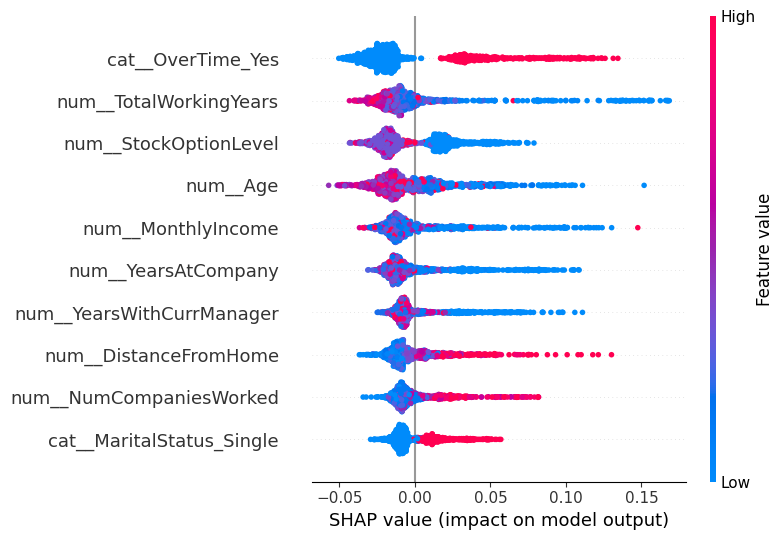


--- 4 e 5. Avaliação do Modelo Preditivo ---


,Abordagem,Accuracy,Precision,Recall,F1-Score
0,Todas as Características (Base),0.8401,0.5000,0.0638,0.1132
1,Filter (Mutual Info),0.8197,0.3636,0.1702,0.2319
2,Wrapper (RFE),0.8197,0.2500,0.0638,0.1017
3,SHAP (Explicabilidade),0.8197,0.3750,0.1915,0.2535


In [6]:

# =====================================================================
# 1. MÉTODO XAI (SHAP) - Extração das Top k Features
# =====================================================================
print("--- 3. Método XAI (SHAP) ---")

# Treinando o modelo compatível com SHAP
rf_shap = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_shap.fit(X_train_proc, y_train)

# Inicialização do TreeExplainer
explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_train_proc)

# Tratamento para as diferentes versões de retorno do scikit-learn/SHAP
if isinstance(shap_values, list):
    # shap_values é uma lista [class0_values, class1_values]
    shap_vals_target = shap_values[1]
else:
    # shap_values é um ndarray (num_samples, num_features, num_classes)
    shap_vals_target = shap_values[:, :, 1]

# Calculando a importância média absoluta para a classe alvo
mean_abs_shap = np.abs(shap_vals_target).mean(axis=0)

# Índices das top k features, ordenados por importância decrescente
top_k_indices_shap = np.argsort(mean_abs_shap)[::-1][:k_features]
shap_features = set(feature_names[top_k_indices_shap])

print(f"Selecionadas {k_features} características (por ordem de importância decrescente):")
for idx in top_k_indices_shap:
    f = feature_names[idx]
    print(f" - {f.replace('num__', '').replace('cat__', '')}")

# Plot Summary para visualização do impacto
shap.summary_plot(shap_vals_target, X_train_proc, feature_names=feature_names, max_display=k_features)


# =====================================================================
# 2. MODELO PREDITIVO - Avaliação dos Subconjuntos
# =====================================================================
print("\n--- 4 e 5. Avaliação do Modelo Preditivo ---")

def avaliar_modelo(indices_features, nome_abordagem):
    """
    Treina o RandomForest e retorna Accuracy, Precision, Recall e F1-Score.
    O class_weight='balanced' ajuda na generalização da classe minoritária (Attrition).
    """
    clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

    # Filtrando X_train e X_test para usar apenas as features da abordagem atual
    X_tr = X_train_proc[:, indices_features]
    X_te = X_test_proc[:, indices_features]

    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    return {
        'Abordagem': nome_abordagem,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

resultados = []

# Mapeando os índices do SHAP para um formato booleano compatível com o slice do numpy
shap_mask = np.isin(np.arange(X_train_proc.shape[1]), top_k_indices_shap)

# Executando a avaliação para as 4 frentes exigidas
resultados.append(avaliar_modelo(np.arange(X_train_proc.shape[1]), 'Todas as Características (Base)'))
resultados.append(avaliar_modelo(filter_selector.get_support(), 'Filter (Mutual Info)'))
resultados.append(avaliar_modelo(wrapper_selector.get_support(), 'Wrapper (RFE)'))
resultados.append(avaliar_modelo(shap_mask, 'SHAP (Explicabilidade)'))

# Tabela de Comparação de Desempenho
df_resultados = pd.DataFrame(resultados)
display(df_resultados.round(4))


# # =====================================================================
# # 3. COMPARAÇÃO COM SHAP - Atributos em Comum e Exclusivos
# # =====================================================================
# print("\n--- Comparação de Características (Comuns e Exclusivas) ---")

# # Encontrando a interseção (consenso) entre os 3 métodos
# comum_todas = filter_features.intersection(wrapper_features).intersection(shap_features)
# print(f"\nCaracterísticas em COMUM entre os 3 métodos ({len(comum_todas)}):")
# for f in sorted(comum_todas):
#     print(f" - {f.replace('num__', '').replace('cat__', '')}")

# # Encontrando as características exclusivas utilizando diferença de conjuntos
# print("\nCaracterísticas EXCLUSIVAS do Filter:")
# for f in sorted(filter_features - wrapper_features - shap_features):
#     print(f" - {f.replace('num__', '').replace('cat__', '')}")

# print("\nCaracterísticas EXCLUSIVAS do Wrapper:")
# for f in sorted(wrapper_features - filter_features - shap_features):
#     print(f" - {f.replace('num__', '').replace('cat__', '')}")

# print("\nCaracterísticas EXCLUSIVAS do SHAP:")
# for f in sorted(shap_features - filter_features - wrapper_features):
#     print(f" - {f.replace('num__', '').replace('cat__', '')}")

## 4,5 e 6. Modelo Preditivo, Avaliação Comparativa com SHAP - Atributos em Comum e Exclusivos e Discussão de Resultados
Avaliaremos um `RandomForestClassifier` (algoritmo não-linear, robusto contra outliers e nativamente explicável) com os 4 subconjuntos de dados:
1. Todas as Features
2. Features Filter
3. Features Wrapper
4. Features SHAP

In [7]:
# =====================================================================
# 4 e 5. MODELO PREDITIVO E AVALIAÇÃO COMPARATIVA (Refatorado)
# =====================================================================
print("--- 4 , 5 e 6. Modelo Preditivo, Avaliação Comparativa com SHAP - Atributos em Comum e Exclusivos e Discussão de Resultados ---")

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

def avaliar_modelo(indices_features, nome_abordagem):
    """
    Treina o modelo RandomForest e retorna métricas médias via cross-validation.
    O class_weight='balanced' ajusta o peso das classes devido ao desbalanceamento comum em problemas de Attrition.
    """
    clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

    # Subconjunto de features
    X_sel = X_train_proc[:, indices_features]

    # Cross-validation estratificada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    acc = cross_val_score(clf, X_sel, y_train, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(clf, X_sel, y_train, cv=cv, scoring='f1').mean()
    prec = cross_val_score(clf, X_sel, y_train, cv=cv, scoring='precision').mean()
    rec  = cross_val_score(clf, X_sel, y_train, cv=cv, scoring='recall').mean()

    return {
        'Abordagem': nome_abordagem,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

resultados = []

# 1. Todas as características
resultados.append(avaliar_modelo(np.arange(X_train_proc.shape[1]), 'Todas as Características (Base)'))

# 2. Filter
resultados.append(avaliar_modelo(filter_selector.get_support(), 'Filter (Mutual Info)'))

# 3. Wrapper
resultados.append(avaliar_modelo(wrapper_selector.get_support(), 'Wrapper (RFE)'))

# 4. SHAP
shap_mask = np.isin(np.arange(X_train_proc.shape[1]), top_k_indices_shap)
resultados.append(avaliar_modelo(shap_mask, 'SHAP (Explicabilidade)'))

# Tabela de Comparação Final
df_resultados = pd.DataFrame(resultados)
display(df_resultados.round(4))

# =====================================================================
# DISCUSSÃO FINAL DOS RESULTADOS
# =====================================================================
print("\n--- Discussão Final ---")

# Identificando a abordagem com o melhor F1-Score
melhor_f1_idx = df_resultados['F1-Score'].idxmax()
melhor_abordagem = df_resultados.loc[melhor_f1_idx, 'Abordagem']
melhor_f1_val = df_resultados.loc[melhor_f1_idx, 'F1-Score']

# Concordância com SHAP
concordancia_filter = len(filter_features.intersection(shap_features))
concordancia_wrapper = len(wrapper_features.intersection(shap_features))

print(f"1. Desempenho:")
print(f"A abordagem que produziu o melhor desempenho global, priorizando o F1-Score, foi '{melhor_abordagem}' com um F1-Score médio de {melhor_f1_val:.4f}.")
print("A validação cruzada garante maior robustez estatística, reduzindo variações de uma única divisão treino/teste.")

print(f"\n2. Concordância com o SHAP:")
print(f" - O método Filter teve {concordancia_filter} de {k_features} características em comum com o SHAP.")
print(f" - O método Wrapper teve {concordancia_wrapper} de {k_features} características em comum com o SHAP.")

if concordancia_wrapper > concordancia_filter:
    print("\nA abordagem Wrapper apresentou maior concordância com o SHAP, pois o RFE utilizou Random Forest como estimador base, avaliando interações não-lineares.")
elif concordancia_filter > concordancia_wrapper:
    print("\nA abordagem Filter apresentou maior concordância com o SHAP neste cenário.")
else:
    print("\nAmbas as abordagens apresentaram o mesmo nível de concordância com o SHAP.")


--- 4 , 5 e 6. Modelo Preditivo, Avaliação Comparativa com SHAP - Atributos em Comum e Exclusivos e Discussão de Resultados ---


,Abordagem,Accuracy,Precision,Recall,F1-Score
0,Todas as Características (Base),0.8563,0.8643,0.1421,0.2383
1,Filter (Mutual Info),0.8512,0.6367,0.2000,0.2922
2,Wrapper (RFE),0.8469,0.6632,0.1368,0.2229
3,SHAP (Explicabilidade),0.8503,0.6316,0.2000,0.2985



--- Discussão Final ---
1. Desempenho:
A abordagem que produziu o melhor desempenho global, priorizando o F1-Score, foi 'SHAP (Explicabilidade)' com um F1-Score médio de 0.2985.
A validação cruzada garante maior robustez estatística, reduzindo variações de uma única divisão treino/teste.

2. Concordância com o SHAP:
 - O método Filter teve 7 de 10 características em comum com o SHAP.
 - O método Wrapper teve 6 de 10 características em comum com o SHAP.

A abordagem Filter apresentou maior concordância com o SHAP neste cenário.
